In [116]:
import pandas as pd
import numpy as np

In [117]:
import os
from pathlib import Path

# Change to results folder
os.chdir(Path(os.getcwd()).parent / 'results')



In [118]:
df = pd.read_csv("prototype-pollution-2.0.csv", header=None)
df = df.drop(columns=[0, 1, 2, 3])

In [119]:
df.head()

,4,5,6,7,8
0,/processed/redos/cejs_2.0.20170212/after/_stru...,882,60,882,64
1,/processed/redos/cejs_2.0.20170212/after/_stru...,882,70,882,74
2,/processed/redos/cejs_2.0.20170212/after/_test...,363,81,363,86
3,/processed/redos/cejs_2.0.20170212/after/appli...,144,60,144,61
4,/processed/redos/cejs_2.0.20170212/after/appli...,71,57,71,59


In [120]:
# Split the file path into parts
parts = df[4].str.strip("/").str.split("/", expand=True)
parts.head()

,0,1,2,3,4,5,6,7,8,9,10
0,processed,redos,cejs_2.0.20170212,after,_structure,dependency_chain.js,NaN,NaN,NaN,NaN,NaN
1,processed,redos,cejs_2.0.20170212,after,_structure,dependency_chain.js,NaN,NaN,NaN,NaN,NaN
2,processed,redos,cejs_2.0.20170212,after,_test suite,test.js,NaN,NaN,NaN,NaN,NaN
3,processed,redos,cejs_2.0.20170212,after,application,OS,Windows,archive.js,NaN,NaN,NaN
4,processed,redos,cejs_2.0.20170212,after,application,math,number_generator.js,NaN,NaN,NaN,NaN


In [121]:
# Add the type and stage columns to the DataFrame
df["type"] = parts[1]
df["stage"] = parts[3]

# Remove rows where stage is not after or before
df = df.drop(df[~df["stage"].isin(["after", "before"])].index, inplace=False)
df

,4,5,6,7,8,type,stage
0,/processed/redos/cejs_2.0.20170212/after/_stru...,882,60,882,64,redos,after
1,/processed/redos/cejs_2.0.20170212/after/_stru...,882,70,882,74,redos,after
2,/processed/redos/cejs_2.0.20170212/after/_test...,363,81,363,86,redos,after
3,/processed/redos/cejs_2.0.20170212/after/appli...,144,60,144,61,redos,after
4,/processed/redos/cejs_2.0.20170212/after/appli...,71,57,71,59,redos,after
...,...,...,...,...,...,...,...
649,/processed/prototype-pollution/nodee-utils_1.2...,30,44,30,49,prototype-pollution,before
650,/processed/redos/ethers_5.2.0/after/misc/React...,68,21,70,10,redos,after
651,/processed/redos/ethers_5.2.0/before/misc/Reac...,68,21,70,10,redos,before
652,/processed/prototype-pollution/firebase-util_0...,2,40,2,43,prototype-pollution,after


In [122]:
# calculate the number of rows for each type and stage
print(df.groupby(["type", "stage"]).size())

type                 stage 
code-injection       after       3
                     before      4
command-injection    after      29
                     before     27
path-traversal       after      10
                     before     15
prototype-pollution  after      81
                     before     88
redos                after     184
                     before    200
dtype: int64


In [123]:
# Filter the DataFrame into two separate DataFrames for before and after
df_redos_before = df[(df["stage"] == "before") & (df["type"] == "redos")]
df_redos_after = df[(df["stage"] == "after") & (df["type"] == "redos")]

df_code_injection_before = df[(df["stage"] == "before") & (df["type"] == "code-injection")]
df_code_injection_after = df[(df["stage"] == "after") & (df["type"] == "code-injection")]

df_command_injection_before = df[(df["stage"] == "before") & (df["type"] == "command-injection")]
df_command_injection_after = df[(df["stage"] == "after") & (df["type"] == "command-injection")]

df_path_traversal_before = df[(df["stage"] == "before") & (df["type"] == "path-traversal")]
df_path_traversal_after = df[(df["stage"] == "after") & (df["type"] == "path-traversal")]

df_prototype_pollution_before = df[(df["stage"] == "before") & (df["type"] == "prototype-pollution")]
df_prototype_pollution_after = df[(df["stage"] == "after") & (df["type"] == "prototype-pollution")] 

print("Sum of redos:", len(df_redos_before) + len(df_redos_after))
print("Sum of code-injection:", len(df_code_injection_before) + len(df_code_injection_after))
print("Sum of command-injection:", len(df_command_injection_before) + len(df_command_injection_after))
print("Sum of path-traversal:", len(df_path_traversal_before) + len(df_path_traversal_after))
print("Sum of prototype-pollution:", len(df_prototype_pollution_before) + len(df_prototype_pollution_after))

print("Sum of all:", len(df_redos_before) + len(df_redos_after) + len(df_code_injection_before) + len(df_code_injection_after) + len(df_command_injection_before) + len(df_command_injection_after) + len(df_path_traversal_before) + len(df_path_traversal_after) + len(df_prototype_pollution_before) + len(df_prototype_pollution_after))

Sum of redos: 384
Sum of code-injection: 7
Sum of command-injection: 56
Sum of path-traversal: 25
Sum of prototype-pollution: 169
Sum of all: 641


In [124]:
# Rename all the columns to be more descriptive
df_redos_before = df_redos_before.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})
df_redos_after = df_redos_after.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})

df_code_injection_before = df_code_injection_before.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})
df_code_injection_after = df_code_injection_after.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})

df_command_injection_before = df_command_injection_before.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})
df_command_injection_after = df_command_injection_after.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})

df_path_traversal_before = df_path_traversal_before.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})
df_path_traversal_after = df_path_traversal_after.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})

df_prototype_pollution_before = df_prototype_pollution_before.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})
df_prototype_pollution_after = df_prototype_pollution_after.rename(columns={4: "file_path", 5: "start_line", 6: "start_column", 7: "end_line", 8: "end_column"})

In [125]:
df_redos_before.head()

,file_path,start_line,start_column,end_line,end_column,type,stage
17,/processed/redos/cejs_2.0.20170212/before/_str...,882,60,882,64,redos,before
18,/processed/redos/cejs_2.0.20170212/before/_str...,882,70,882,74,redos,before
19,/processed/redos/cejs_2.0.20170212/before/_tes...,363,81,363,86,redos,before
20,/processed/redos/cejs_2.0.20170212/before/appl...,144,60,144,61,redos,before
21,/processed/redos/cejs_2.0.20170212/before/appl...,71,57,71,59,redos,before


In [126]:
os.chdir(Path(os.getcwd()).parent / 'data-processing')

In [127]:
os.getcwd()

'c:\\codeql_docker\\data-processing'

In [128]:
!pip install tree-sitter tree_sitter_javascript


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [129]:
from utils import add_vulnerable_function_to_df

df_redos_before = add_vulnerable_function_to_df(df_redos_before)
df_redos_after = add_vulnerable_function_to_df(df_redos_after)

df_code_injection_before = add_vulnerable_function_to_df(df_code_injection_before)
df_code_injection_after = add_vulnerable_function_to_df(df_code_injection_after)

df_command_injection_before = add_vulnerable_function_to_df(df_command_injection_before)
df_command_injection_after = add_vulnerable_function_to_df(df_command_injection_after)

df_path_traversal_before = add_vulnerable_function_to_df(df_path_traversal_before)
df_path_traversal_after = add_vulnerable_function_to_df(df_path_traversal_after)

df_prototype_pollution_before = add_vulnerable_function_to_df(df_prototype_pollution_before)
df_prototype_pollution_after = add_vulnerable_function_to_df(df_prototype_pollution_after)

In [130]:
print("Sum of redos before:", len(df_redos_before))
print(f"Sum of vulnerable function in redos before: {df_redos_before['vulnerable_function'].value_counts().sum()} and the NaN values are {df_redos_before['vulnerable_function'].isna().sum()}")
print("Sum of redos after:", len(df_redos_after))
print(f"Sum of vulnerable function in redos after: {df_redos_after['vulnerable_function'].value_counts().sum()} and the NaN values are {df_redos_after['vulnerable_function'].isna().sum()}")

print("Sum of code-injection before:", len(df_code_injection_before))
print(f"Sum of vulnerable function in code-injection before: {df_code_injection_before['vulnerable_function'].value_counts().sum()} and the NaN values are {df_code_injection_before['vulnerable_function'].isna().sum()}")
print("Sum of code-injection after:", len(df_code_injection_after))
print(f"Sum of vulnerable function in code-injection after: {df_code_injection_after['vulnerable_function'].value_counts().sum()} and the NaN values are {df_code_injection_after['vulnerable_function'].isna().sum()}")

print("Sum of command-injection before:", len(df_command_injection_before))
print(f"Sum of vulnerable function in command-injection before: {df_command_injection_before['vulnerable_function'].value_counts().sum()} and the NaN values are {df_command_injection_before['vulnerable_function'].isna().sum()}")
print("Sum of command-injection after:", len(df_command_injection_after))
print(f"Sum of vulnerable function in command-injection after: {df_command_injection_after['vulnerable_function'].value_counts().sum()} and the NaN values are {df_command_injection_after['vulnerable_function'].isna().sum()}")  

print("Sum of path-traversal before:", len(df_path_traversal_before))
print(f"Sum of vulnerable function in path-traversal before: {df_path_traversal_before['vulnerable_function'].value_counts().sum()} and the NaN values are {df_path_traversal_before['vulnerable_function'].isna().sum()}")
print("Sum of path-traversal after:", len(df_path_traversal_after))
print(f"Sum of vulnerable function in path-traversal after: {df_path_traversal_after['vulnerable_function'].value_counts().sum()} and the NaN values are {df_path_traversal_after['vulnerable_function'].isna().sum()}")

print("Sum of prototype pollution before:", len(df_prototype_pollution_before))
print(f"Sum of vulnerable function in prototype pollution before: {df_prototype_pollution_before['vulnerable_function'].value_counts().sum()} and the NaN values are {df_prototype_pollution_before['vulnerable_function'].isna().sum()}")
print("Sum of prototype pollution after:", len(df_prototype_pollution_after))
print(f"Sum of vulnerable function in prototype pollution after: {df_prototype_pollution_after['vulnerable_function'].value_counts().sum()} and the NaN values are {df_prototype_pollution_after['vulnerable_function'].isna().sum()}")

Sum of redos before: 200
Sum of vulnerable function in redos before: 88 and the NaN values are 112
Sum of redos after: 184
Sum of vulnerable function in redos after: 84 and the NaN values are 100
Sum of code-injection before: 4
Sum of vulnerable function in code-injection before: 0 and the NaN values are 4
Sum of code-injection after: 3
Sum of vulnerable function in code-injection after: 0 and the NaN values are 3
Sum of command-injection before: 27
Sum of vulnerable function in command-injection before: 9 and the NaN values are 18
Sum of command-injection after: 29
Sum of vulnerable function in command-injection after: 14 and the NaN values are 15
Sum of path-traversal before: 15
Sum of vulnerable function in path-traversal before: 1 and the NaN values are 14
Sum of path-traversal after: 10
Sum of vulnerable function in path-traversal after: 0 and the NaN values are 10
Sum of prototype pollution before: 88
Sum of vulnerable function in prototype pollution before: 35 and the NaN values

In [131]:
print(len(df_redos_before.drop_duplicates()))
print(len(df_redos_after.drop_duplicates()))

200
184


In [132]:
from utils import normalize_stage_in_path, count_bugs

df_redos_before = df_redos_before.copy()
df_redos_after = df_redos_after.copy()

df_redos_before["path_norm"] = df_redos_before["file_path"].map(normalize_stage_in_path)
df_redos_after["path_norm"] = df_redos_after["file_path"].map(normalize_stage_in_path)

df_redos_before["start_line_diff"] = df_redos_before["start_line"] - df_redos_before["end_line"]
df_redos_before["end_line_diff"] = df_redos_before["end_line"] - df_redos_before["start_line"]
df_redos_after["start_line_diff"] = df_redos_after["start_line"] - df_redos_after["end_line"]
df_redos_after["end_line_diff"] = df_redos_after["end_line"] - df_redos_after["start_line"]

num_of_bugs_in_both, num_of_bugs_only_in_before, num_of_bugs_only_in_after, num_of_bugs_changed = count_bugs(df_redos_before, df_redos_after)

print("Number of bugs appearing in both stages for redos:", num_of_bugs_in_both)
print("Number of bugs only appearing in the before stage for redos:", num_of_bugs_only_in_before)
print("Number of bugs only appearing in the after stage for redos:", num_of_bugs_only_in_after)
print("Number of bugs that changed position for redos:", num_of_bugs_changed)

Number of bugs appearing in both stages for redos: 168
Number of bugs only appearing in the before stage for redos: 4
Number of bugs only appearing in the after stage for redos: 0
Number of bugs that changed position for redos: 16


In [133]:
df_path_traversal_before = df_path_traversal_before.copy()
df_path_traversal_after = df_path_traversal_after.copy()
df_path_traversal_before["path_norm"] = df_path_traversal_before["file_path"].map(normalize_stage_in_path)
df_path_traversal_after["path_norm"] = df_path_traversal_after["file_path"].map(normalize_stage_in_path)

num_of_bugs_in_both, num_of_bugs_only_in_before, num_of_bugs_only_in_after, num_of_bugs_changed = count_bugs(df_path_traversal_before, df_path_traversal_after)

print("Number of bugs appearing in both stages for path traversal:", num_of_bugs_in_both)
print("Number of bugs only appearing in the before stage for path traversal:", num_of_bugs_only_in_before)
print("Number of bugs only appearing in the after stage for path traversal:", num_of_bugs_only_in_after)
print("Number of bugs that changed position for path traversal:", num_of_bugs_changed)


Number of bugs appearing in both stages for path traversal: 4
Number of bugs only appearing in the before stage for path traversal: 1
Number of bugs only appearing in the after stage for path traversal: 0
Number of bugs that changed position for path traversal: 6


In [134]:
df_code_injection_before = df_code_injection_before.copy()
df_code_injection_after = df_code_injection_after.copy()
df_code_injection_before["path_norm"] = df_code_injection_before["file_path"].map(normalize_stage_in_path)
df_code_injection_after["path_norm"] = df_code_injection_after["file_path"].map(normalize_stage_in_path)

num_of_bugs_in_both, num_of_bugs_only_in_before, num_of_bugs_only_in_after, num_of_bugs_changed = count_bugs(df_code_injection_before, df_code_injection_after)

print("Number of bugs appearing in both stages for code injection:", num_of_bugs_in_both)
print("Number of bugs only appearing in the before stage for code injection:", num_of_bugs_only_in_before)
print("Number of bugs only appearing in the after stage for code injection:", num_of_bugs_only_in_after)
print("Number of bugs that changed position for code injection:", num_of_bugs_changed)

Number of bugs appearing in both stages for code injection: 3
Number of bugs only appearing in the before stage for code injection: 1
Number of bugs only appearing in the after stage for code injection: 0
Number of bugs that changed position for code injection: 0


In [135]:
df_command_injection_before = df_command_injection_before.copy()
df_command_injection_after = df_command_injection_after.copy()

df_command_injection_before["path_norm"] = df_command_injection_before["file_path"].map(normalize_stage_in_path)
df_command_injection_after["path_norm"] = df_command_injection_after["file_path"].map(normalize_stage_in_path)

num_of_bugs_in_both, num_of_bugs_only_in_before, num_of_bugs_only_in_after, num_of_bugs_changed = count_bugs(df_command_injection_before, df_command_injection_after)

print("Number of bugs appearing in both stages for command injection:", num_of_bugs_in_both)
print("Number of bugs only appearing in the before stage for command injection:", num_of_bugs_only_in_before)
print("Number of bugs only appearing in the after stage for command injection:", num_of_bugs_only_in_after)
print("Number of bugs that changed position for command injection:", num_of_bugs_changed)

Number of bugs appearing in both stages for command injection: 22
Number of bugs only appearing in the before stage for command injection: 1
Number of bugs only appearing in the after stage for command injection: 5
Number of bugs that changed position for command injection: 2


In [136]:
df_prototype_pollution_before = df_prototype_pollution_before.copy()
df_prototype_pollution_after = df_prototype_pollution_after.copy()

df_prototype_pollution_before["path_norm"] = df_prototype_pollution_before["file_path"].map(normalize_stage_in_path)
df_prototype_pollution_after["path_norm"] = df_prototype_pollution_after["file_path"].map(normalize_stage_in_path)

num_of_bugs_in_both, num_of_bugs_only_in_before, num_of_bugs_only_in_after, num_of_bugs_changed = count_bugs(df_prototype_pollution_before, df_prototype_pollution_after)

print("Number of bugs appearing in both stages for prototype pollution:", num_of_bugs_in_both)
print("Number of bugs only appearing in the before stage for prototype pollution:", num_of_bugs_only_in_before)
print("Number of bugs only appearing in the after stage for prototype pollution:", num_of_bugs_only_in_after)
print("Number of bugs that changed position for prototype pollution:", num_of_bugs_changed)

Number of bugs appearing in both stages for prototype pollution: 79
Number of bugs only appearing in the before stage for prototype pollution: 3
Number of bugs only appearing in the after stage for prototype pollution: 0
Number of bugs that changed position for prototype pollution: 2


In [137]:
from utils import add_CVE_from_path

df_redos_before = add_CVE_from_path(df_redos_before)
df_redos_after = add_CVE_from_path(df_redos_after)

df_code_injection_before = add_CVE_from_path(df_code_injection_before)
df_code_injection_after = add_CVE_from_path(df_code_injection_after)

df_command_injection_before = add_CVE_from_path(df_command_injection_before)
df_command_injection_after = add_CVE_from_path(df_command_injection_after)

df_path_traversal_before = add_CVE_from_path(df_path_traversal_before)
df_path_traversal_after = add_CVE_from_path(df_path_traversal_after)

df_prototype_pollution_before = add_CVE_from_path(df_prototype_pollution_before)
df_prototype_pollution_after = add_CVE_from_path(df_prototype_pollution_after)

In [138]:
from utils import count_bugs_per_CVE

redos_per_cve = count_bugs_per_CVE(df_redos_before, df_redos_after)
code_injection_per_cve = count_bugs_per_CVE(df_code_injection_before, df_code_injection_after)
command_injection_per_cve = count_bugs_per_CVE(df_command_injection_before, df_command_injection_after)
path_traversal_per_cve = count_bugs_per_CVE(df_path_traversal_before, df_path_traversal_after)
prototype_pollution_per_cve = count_bugs_per_CVE(df_prototype_pollution_before, df_prototype_pollution_after)

In [139]:
all_dfs = [redos_per_cve, code_injection_per_cve, command_injection_per_cve, path_traversal_per_cve, prototype_pollution_per_cve]

df_cve_results = pd.concat(all_dfs, ignore_index=True)

df_cve_results.to_csv("cve_results.csv", index=False)

In [140]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [141]:
df = df_cve_results.copy()

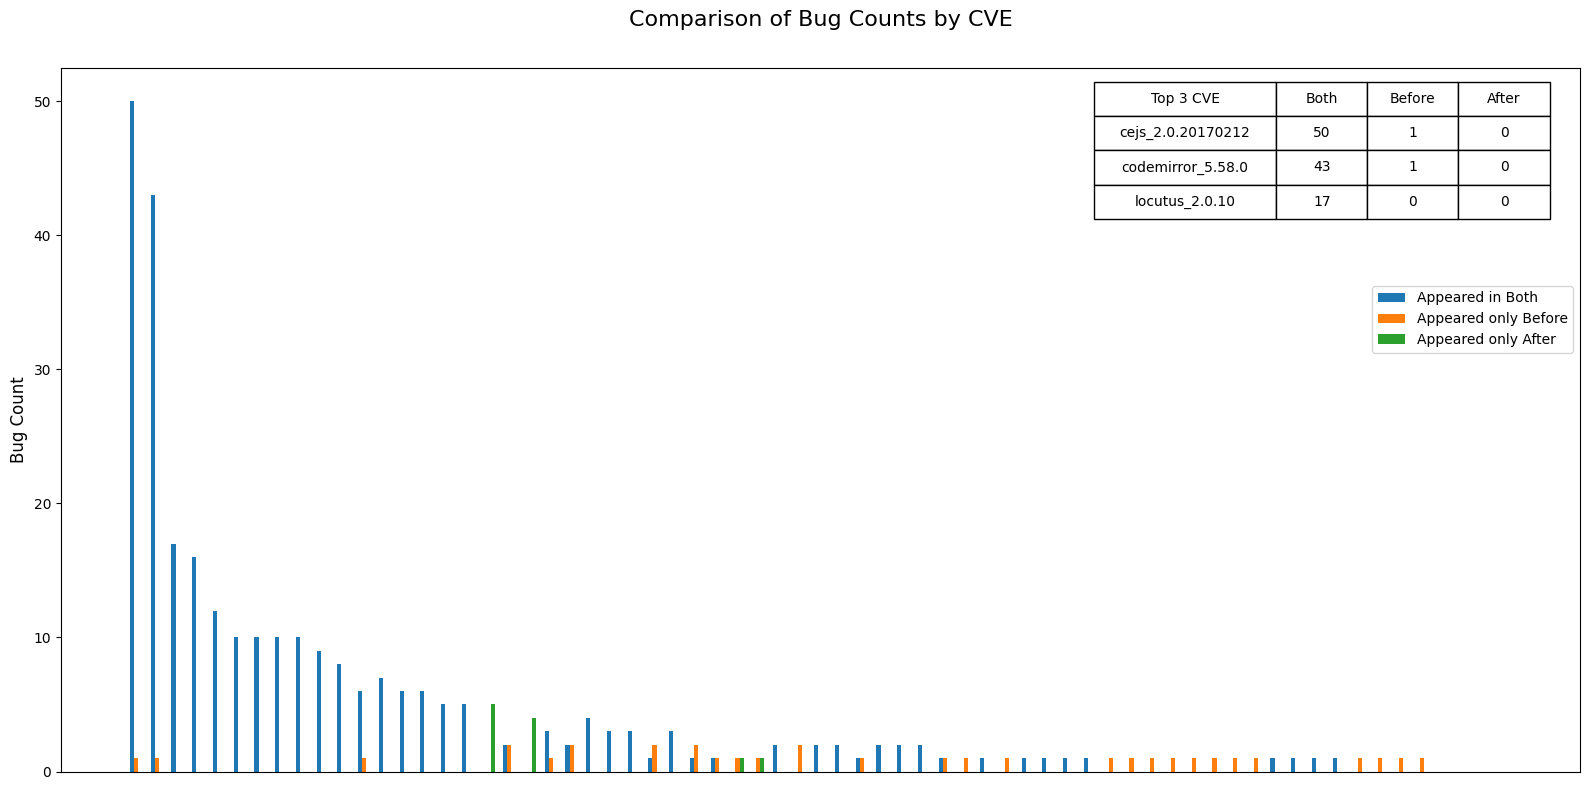

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Giả sử df là dữ liệu của bạn
df['total'] = df['both'] + df['only_before'] + df['only_after']
df_plot = df.sort_values(by='total', ascending=False).reset_index(drop=True)

# Lấy dữ liệu Top 3 để đưa vào bảng
top_3_df = df_plot.head(3)[['CVE', 'both', 'only_before', 'only_after']]
table_data = top_3_df.values.tolist()
table_columns = ['Top 3 CVE', 'Both', 'Before', 'After']

# 2. Thiết lập biểu đồ
x = np.arange(len(df_plot))
width = 0.2 # Khoảng cách thưa giữa các CVE

fig, ax = plt.subplots(figsize=(16, 8))

# Vẽ các cột
ax.bar(x - width, df_plot['both'], width, label='Appeared in Both', color='#1f77b4')
ax.bar(x, df_plot['only_before'], width, label='Appeared only Before', color='#ff7f0e')
ax.bar(x + width, df_plot['only_after'], width, label='Appeared only After', color='#2ca02c')

# 3. CHÈN BẢNG VÀO TRONG ĐỒ THỊ
# loc='upper right' đặt bảng ở góc trên bên phải
the_table = ax.table(cellText=table_data,
                      colLabels=table_columns,
                      loc='upper right',
                      colWidths=[0.1, 0.05, 0.05, 0.05], # Độ rộng các cột trong bảng
                      cellLoc='center')

# Định dạng bảng cho dễ nhìn
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.8) # Phóng to các ô trong bảng (chiều ngang, chiều dọc)

# 4. Trang trí biểu đồ
ax.set_ylabel('Bug Count', fontsize=12)
ax.set_title('Comparison of Bug Counts by CVE', fontsize=16, pad=30)
ax.set_xticks([]) # Ẩn tên CVE ở trục X để tránh đè nhau
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.7)) # Đẩy chú thích xuống dưới bảng một chút

plt.tight_layout()
plt.savefig('cve_comparison.png', dpi=300)
plt.show()

